# 217 — RBH false positives: paralog contamination check

Notebook 200 section 7 built RBH ("Homolog Prediction") calls per alphabet/k-size and compared them
against MGI ("Known Homolog") truth. Some RBH calls are not in MGI, a false positive by that
comparison. The follow-up, echoing notebook 124's earlier check against a much more selective
calling rule: are those non-MGI RBH calls random noise, or still biologically related to their RBH
partner — same gene family or paralog, the failure mode expected of a single-best-hit rule when a
gene has undergone lineage-specific duplication?

**Why redo notebook 124's check rather than reuse it.** Notebook 124 used the Bonferroni-significance
threshold from notebook 120, since shown (notebook 200 section 2) to badly over-call: 7.29M
"significant" pairs, 99.8% not even in OrthoFinder's orthogroup mapping and therefore not scoreable,
against RBH's ~15-19k calls per combo, one per human gene. Same proxy (OrthoFinder orthogroup
co-membership as paralog family), far cleaner denominator.

**Method.** For each of the 8 alphabets from notebook 200 section 7, at that alphabet's best-F1
k-size, split RBH calls into MGI-confirmed and not-MGI, and check whether the two genes in each pair
share an OrthoFinder orthogroup. Built at the GENE level (any isoform in common), since the RBH pair
table is gene-level, unlike notebook 124's protein-level check.

## 1. Load data

In [1]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

ENCODINGS = [
    "protein",
    "dayhoff",
    "hp",
    "hp_lehninger_plus_c",
    "hp_kyte_doolittle",
    "hp_pbotc_1st_ed",
    "hp_thomas_dill",
    "hp_thomas_dill_no_c",
]
# Same dash-name quirk as notebook 200's imports cell: the 5 genuinely-distinct HP variants have
# dash-named raw results files/pair_cache entries; "protein", "dayhoff", "hp" pass through as-is.
HP_VARIANT_DASH_TO_LABEL = {
    "hp-lehninger": "hp_lehninger",
    "hp-lehninger-plus-c": "hp_lehninger_plus_c",
    "hp-kyte-doolittle": "hp_kyte_doolittle",
    "hp-pbotc-1st-ed": "hp_pbotc_1st_ed",
    "hp-thomas-dill": "hp_thomas_dill",
    "hp-thomas-dill-no-c": "hp_thomas_dill_no_c",
}
LABEL_TO_DASH = {label: dash for dash, label in HP_VARIANT_DASH_TO_LABEL.items()}


def file_encoding(enc: str) -> str:
    return LABEL_TO_DASH.get(enc, enc)


# Full per-alphabet k-ranges (same as notebook 200) -- section 2 sweeps ALL of these,
# not just each alphabet's best-F1 k, so any specific combo (e.g. hp_pbotc_1st_ed k=19)
# can be inspected directly in contamination_df/jaccard_df below.
ALPHABET_KSIZES = {
    "hp": range(21, 31),
    "dayhoff": range(10, 21),
    "protein": range(5, 16),
}
HP_VARIANT_KSIZES = range(18, 31)


def ksizes_for(enc: str) -> range:
    return ALPHABET_KSIZES[enc] if enc in ALPHABET_KSIZES else HP_VARIANT_KSIZES


print("Config OK")

Config OK


In [2]:
# MGI ground truth -- same as notebook 200 section 1
mgi_raw = pl.read_csv(
    DATA_DIR / "HOM_MouseHumanSequence.rpt",
    separator="\t",
    null_values=[""],
    infer_schema_length=10_000,
)
human_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)
mgi_pairs = (
    human_rows.join(mouse_rows, on="DB Class Key")
    .with_columns(
        [
            pl.col("human_symbol").str.to_uppercase().alias("human_gene"),
            pl.col("mouse_symbol").str.to_uppercase().alias("mouse_gene"),
        ]
    )
    .select(["human_gene", "mouse_gene"])
    .unique()
)
print(f"MGI ortholog pairs: {len(mgi_pairs):,}")

MGI ortholog pairs: 24,584


In [3]:
# OrthoFinder orthogroups, collapsed to GENE level (notebook 124 checked this at the protein
# level -- query_name/target_name from the raw kmerseek hits -- but the RBH pair table here is
# already gene-level, so a gene's orthogroup set is the union over all its protein isoforms).
ORTHOGROUPS_TSV = OF_DIR / "Orthogroups/Orthogroups.tsv"
H_COL, M_COL = "gencode.v49.pc_translations", "gencode.vM38.pc_translations"


def gene_from_protein_id(pid: str) -> str:
    parts = pid.split("|")
    return parts[-2].upper() if len(parts) >= 2 else pid.upper()


human_gene_ogs: dict[str, set] = {}
mouse_gene_ogs: dict[str, set] = {}
with open(ORTHOGROUPS_TSV) as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        og = row["Orthogroup"]
        for pid in (row[H_COL] or "").split(","):
            pid = pid.strip()
            if pid:
                human_gene_ogs.setdefault(gene_from_protein_id(pid), set()).add(og)
        for pid in (row[M_COL] or "").split(","):
            pid = pid.strip()
            if pid:
                mouse_gene_ogs.setdefault(gene_from_protein_id(pid), set()).add(og)

print(f"Human genes with an orthogroup: {len(human_gene_ogs):,}")
print(f"Mouse genes with an orthogroup: {len(mouse_gene_ogs):,}")


def same_orthogroup(human_gene: str, mouse_gene: str) -> bool | None:
    """True/False if both genes have orthogroup data and share >=1 OG; None if either gene is
    entirely missing from OrthoFinder's mapping (can't be checked -- excluded from rates below,
    same "scoreable" restriction notebook 124 used)."""
    h_ogs = human_gene_ogs.get(human_gene)
    m_ogs = mouse_gene_ogs.get(mouse_gene)
    if h_ogs is None or m_ogs is None:
        return None
    return bool(h_ogs & m_ogs)

Human genes with an orthogroup: 20,249
Mouse genes with an orthogroup: 21,755


In [4]:
# Best-F1 k-size per alphabet, from the cached sweep CSVs notebook 200 already produced
# (no need to recompute the sweep here).
sweep = pl.read_csv(DATA_DIR / "200_alphabet_ksize_matched_scope_comparison.csv")
hp_variants = pl.read_csv(DATA_DIR / "200_hp_variants_full_sweep.csv")
sweep_df_ext = pl.concat(
    [
        sweep.select(["encoding", "ksize", "kmerseek_F1"]),
        hp_variants.select(["encoding", "ksize", "kmerseek_F1"]),
    ],
    how="diagonal_relaxed",
)
best_k_per_alphabet = {
    enc: sweep_df_ext.filter(pl.col("encoding") == enc).sort(
        "kmerseek_F1", descending=True
    )["ksize"][0]
    for enc in ENCODINGS
}
print("Best-F1 k-size per alphabet:", best_k_per_alphabet)

Best-F1 k-size per alphabet: {'protein': 15, 'dayhoff': 20, 'hp': 30, 'hp_lehninger_plus_c': 30, 'hp_kyte_doolittle': 30, 'hp_pbotc_1st_ed': 30, 'hp_thomas_dill': 30, 'hp_thomas_dill_no_c': 30}


## 2. RBH calls, annotated with MGI truth and orthogroup co-membership

In [5]:
# For EVERY (alphabet, k-size) combo (not just the best-F1 k): RBH calls, split MGI-confirmed
# vs. not, and orthogroup co-membership. rbh_pairs_and_scope/load_pair_table read from
# notebook 200's pair_cache -- cache hits are near-instant, but a handful of combos (mostly the
# smallest k per HP variant) were never cached. An earlier version of this cell size-guarded
# uncached files by COMPRESSED size and scanned anything under 5GB inline -- that's the wrong
# check: this project's own documented gotcha is that polars does not stream compressed CSV, so a
# multi-GB compressed file can decompress to 100x its size in RAM (a 1.9GB case measured at
# 184.7GB uncompressed). That crashed the kernel here. Skip ANY uncached combo unconditionally --
# building a new cache safely is `scripts/convert_results_to_parquet_streaming.py`'s job, not an
# inline scan in this notebook.
rbh_tables = {}  # (encoding, ksize) -> annotated df
contamination_rows = []
skipped_uncached = []
for enc in ENCODINGS:
    fenc = file_encoding(enc)
    for k in ksizes_for(enc):
        cache_path = ou.PAIR_CACHE_DIR / f"{fenc}_k{k}_jaccard.parquet"
        if not cache_path.exists():
            skipped_uncached.append((enc, k))
            continue

        try:
            rbh_set, scope = ou.rbh_pairs_and_scope(fenc, k, DATA_DIR)
        except (
            FileNotFoundError,
            pl.exceptions.NoDataError,
            pl.exceptions.ComputeError,
        ):
            continue
        mgi_scope = mgi_pairs.filter(pl.col("human_gene").is_in(list(scope)))
        mgi_scope_set = set(
            zip(mgi_scope["human_gene"].to_list(), mgi_scope["mouse_gene"].to_list())
        )

        rows = [
            {
                "human_gene": h,
                "mouse_gene": m,
                "is_mgi_ortholog": (h, m) in mgi_scope_set,
                "same_orthogroup": same_orthogroup(h, m),
            }
            for h, m in rbh_set
        ]
        df = pl.DataFrame(rows)
        rbh_tables[(enc, k)] = df

        fp_scoreable = df.filter(
            ~pl.col("is_mgi_ortholog") & pl.col("same_orthogroup").is_not_null()
        )
        tp_scoreable = df.filter(
            pl.col("is_mgi_ortholog") & pl.col("same_orthogroup").is_not_null()
        )

        contamination_rows.append(
            {
                "encoding": enc,
                "ksize": k,
                "n_rbh_calls": df.height,
                "n_fp": int((~df["is_mgi_ortholog"]).sum()),
                "n_fp_scoreable": fp_scoreable.height,
                "fp_same_orthogroup_rate": (
                    fp_scoreable["same_orthogroup"].mean()
                    if fp_scoreable.height
                    else float("nan")
                ),
                "n_tp": int(df["is_mgi_ortholog"].sum()),
                "n_tp_scoreable": tp_scoreable.height,
                "tp_same_orthogroup_rate": (
                    tp_scoreable["same_orthogroup"].mean()
                    if tp_scoreable.height
                    else float("nan")
                ),
            }
        )

contamination_df = pl.DataFrame(contamination_rows).sort(["encoding", "ksize"])
print(f"Built contamination stats for {contamination_df.height} alphabet/ksize combos")
if skipped_uncached:
    print(f"Skipped {len(skipped_uncached)} uncached combos (no pair_cache entry):")
    for enc, k in skipped_uncached:
        print(f"  {enc} k={k}")
contamination_df

Built contamination stats for 88 alphabet/ksize combos
Skipped 9 uncached combos (no pair_cache entry):
  hp k=21
  hp k=23
  hp k=25
  hp_kyte_doolittle k=19
  hp_pbotc_1st_ed k=18
  hp_thomas_dill k=18
  hp_thomas_dill k=19
  hp_thomas_dill_no_c k=18
  hp_thomas_dill_no_c k=19


encoding,ksize,n_rbh_calls,n_fp,n_fp_scoreable,fp_same_orthogroup_rate,n_tp,n_tp_scoreable,tp_same_orthogroup_rate
str,i64,i64,i64,i64,f64,i64,i64,f64
"""dayhoff""",10,8733,410,375,0.386667,8323,8290,0.991797
"""dayhoff""",11,16492,558,513,0.559454,15934,15862,0.991174
"""dayhoff""",12,16438,546,500,0.56,15892,15825,0.991343
"""dayhoff""",13,16401,544,498,0.554217,15857,15794,0.991389
"""dayhoff""",14,16349,541,495,0.535354,15808,15747,0.991871
…,…,…,…,…,…,…,…,…
"""protein""",11,16482,464,425,0.663529,16018,15962,0.993485
"""protein""",12,16319,447,409,0.669927,15872,15816,0.993993
"""protein""",13,16140,435,398,0.653266,15705,15653,0.994059


## 3. Figure: paralog contamination rate, false positives vs. true positives, per alphabet

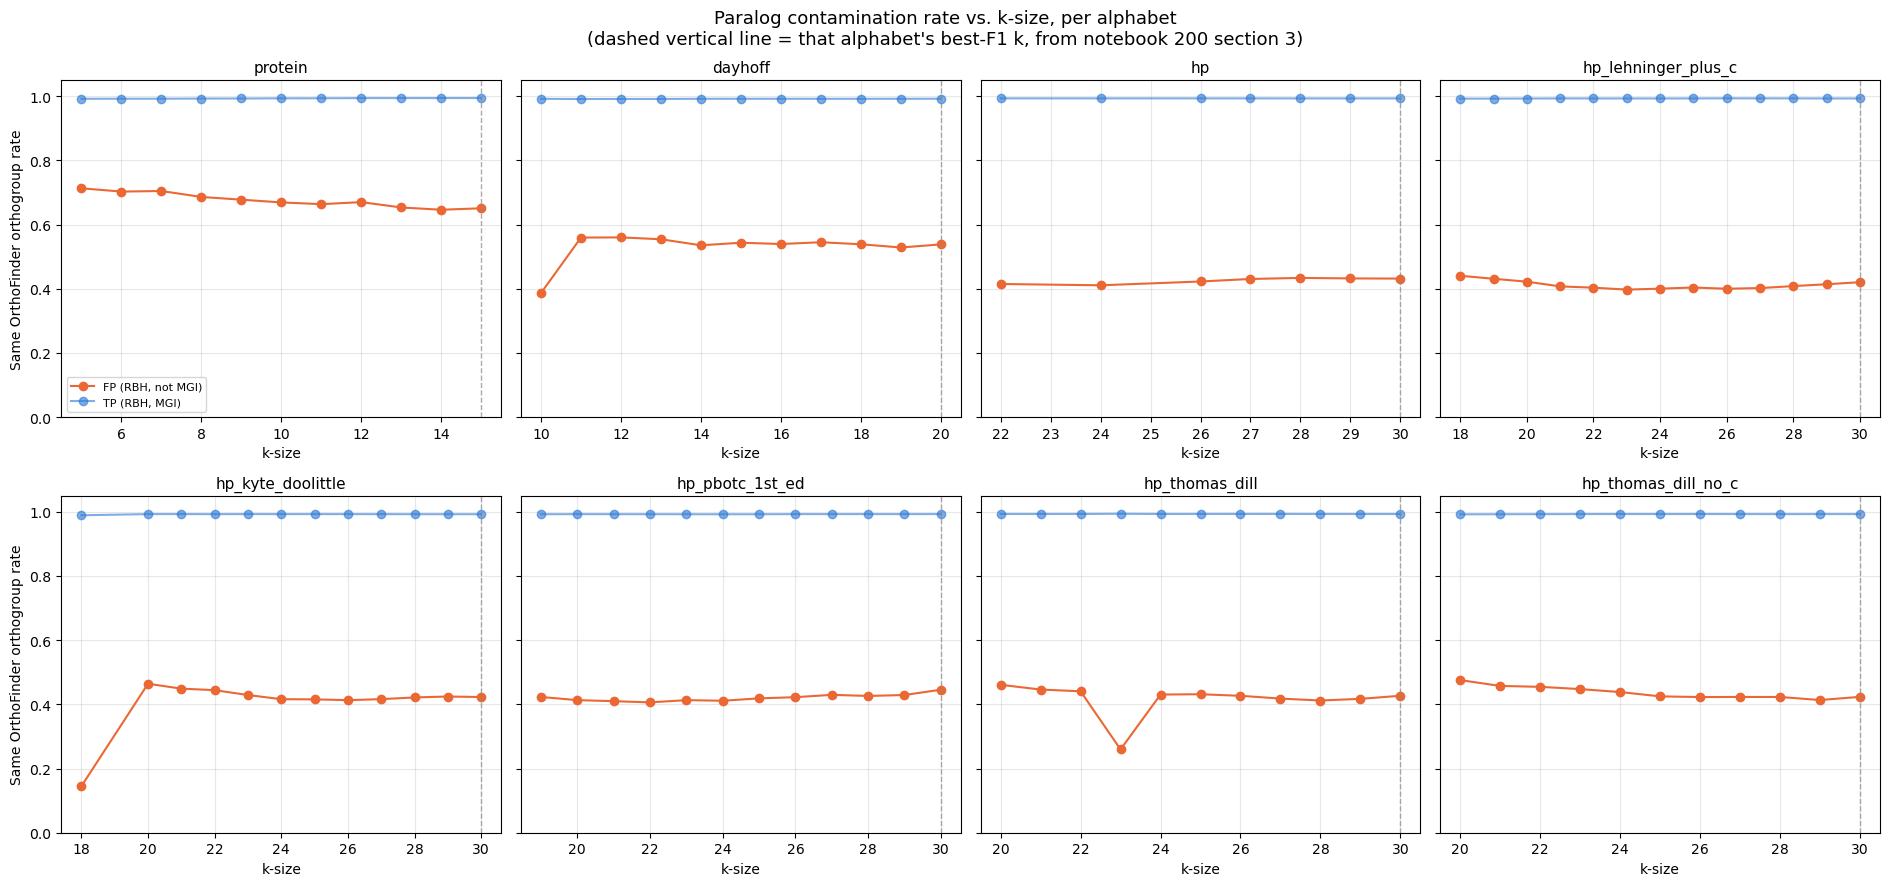

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    sub = contamination_df.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(
        sub["ksize"],
        sub["fp_same_orthogroup_rate"],
        "o-",
        color="#eb6834",
        label="FP (RBH, not MGI)",
    )
    ax.plot(
        sub["ksize"],
        sub["tp_same_orthogroup_rate"],
        "o-",
        color="#2a78d6",
        label="TP (RBH, MGI)",
        alpha=0.6,
    )
    ax.axvline(best_k_per_alphabet[enc], color="#888888", ls="--", lw=1, alpha=0.7)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("k-size")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel("Same OrthoFinder orthogroup rate")
fig.suptitle(
    "Paralog contamination rate vs. k-size, per alphabet\n"
    "(dashed vertical line = that alphabet's best-F1 k, from notebook 200 section 3)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "217_contamination_vs_ksize.png", dpi=150, bbox_inches="tight")

## 4. Does the continuous jaccard score distinguish paralog-driven FPs from noise?

RBH already reduces the false-positive set to same-family about half the time (section 3). The
follow-up: within that set, does the raw **jaccard** score — the continuous signal RBH is built on,
not just the binary call — say *which kind* of mistake this is? A paralog swap (same orthogroup:
real k-mer signal, wrong duplicate) should score higher than a spurious match (different orthogroup:
closer to coincidental overlap). `jaccard` comes from the same `ou.load_pair_table` cache RBH
selection uses, joined onto each RBH-called pair.

In [7]:
rbh_tables_scored = {}
for (enc, k), rbh_df in rbh_tables.items():
    fenc = file_encoding(enc)
    jac = ou.load_pair_table(fenc, k, DATA_DIR)
    rbh_tables_scored[(enc, k)] = rbh_df.join(
        jac, on=["human_gene", "mouse_gene"], how="left"
    )

rbh_tables_scored[("protein", best_k_per_alphabet["protein"])].head()

human_gene,mouse_gene,is_mgi_ortholog,same_orthogroup,jaccard
str,str,bool,bool,f64
"""SPMIP1""","""SPMIP1""",true,true,0.058632
"""MPDZ""","""MPDZ""",true,true,0.173231
"""CHRNA5""","""CHRNA5""",true,true,0.199735
"""RBP3""","""RBP3""",true,true,0.099507
"""UEVLD""","""UEVLD""",true,true,0.05787


In [8]:
from sklearn.metrics import roc_auc_score

# Over ALL (encoding, ksize) combos, not just best-F1 k -- so any specific combo (e.g.
# hp_pbotc_1st_ed k=19) can be inspected directly in jaccard_df below.
jaccard_rows = []
for (enc, k), df in rbh_tables_scored.items():
    fp = df.filter(~pl.col("is_mgi_ortholog") & pl.col("same_orthogroup").is_not_null())
    fp_same = fp.filter(pl.col("same_orthogroup"))["jaccard"].to_list()
    fp_diff = fp.filter(~pl.col("same_orthogroup"))["jaccard"].to_list()

    p_mwu = ou.safe_mwu(fp_same, fp_diff)
    if len(fp_same) >= 2 and len(fp_diff) >= 2:
        auc = roc_auc_score(fp["same_orthogroup"].to_numpy(), fp["jaccard"].to_numpy())
    else:
        auc = float("nan")

    jaccard_rows.append(
        {
            "encoding": enc,
            "ksize": k,
            "n_fp_same": len(fp_same),
            "median_jaccard_fp_same": (
                float(np.median(fp_same)) if fp_same else float("nan")
            ),
            "n_fp_diff": len(fp_diff),
            "median_jaccard_fp_diff": (
                float(np.median(fp_diff)) if fp_diff else float("nan")
            ),
            "mwu_pvalue": p_mwu,
            "roc_auc_same_orthogroup": auc,
        }
    )

jaccard_df = pl.DataFrame(jaccard_rows).sort(["encoding", "ksize"])
print(f"Built jaccard stats for {jaccard_df.height} alphabet/ksize combos")
best_k_jaccard = pl.concat(
    [
        jaccard_df.filter(
            (pl.col("encoding") == enc) & (pl.col("ksize") == best_k_per_alphabet[enc])
        )
        for enc in ENCODINGS
    ]
)
print(
    "\nAt each alphabet's best-F1 k -- jaccard separating same-orthogroup FPs from diff-orthogroup FPs:"
)
print(
    best_k_jaccard.select(
        [
            "encoding",
            "ksize",
            "n_fp_same",
            "n_fp_diff",
            "mwu_pvalue",
            "roc_auc_same_orthogroup",
        ]
    )
)

print("\nThe specific combo asked about, hp_pbotc_1st_ed k=19:")
jaccard_df.filter((pl.col("encoding") == "hp_pbotc_1st_ed") & (pl.col("ksize") == 19))

Built jaccard stats for 88 alphabet/ksize combos

At each alphabet's best-F1 k -- jaccard separating same-orthogroup FPs from diff-orthogroup FPs:
shape: (8, 6)
┌─────────────────────┬───────┬───────────┬───────────┬────────────┬─────────────────────────┐
│ encoding            ┆ ksize ┆ n_fp_same ┆ n_fp_diff ┆ mwu_pvalue ┆ roc_auc_same_orthogroup │
│ ---                 ┆ ---   ┆ ---       ┆ ---       ┆ ---        ┆ ---                     │
│ str                 ┆ i64   ┆ i64       ┆ i64       ┆ f64        ┆ f64                     │
╞═════════════════════╪═══════╪═══════════╪═══════════╪════════════╪═════════════════════════╡
│ protein             ┆ 15    ┆ 244       ┆ 131       ┆ 0.143091   ┆ 0.545864                │
│ dayhoff             ┆ 20    ┆ 247       ┆ 212       ┆ 0.067167   ┆ 0.549538                │
│ hp                  ┆ 30    ┆ 221       ┆ 291       ┆ 3.1341e-7  ┆ 0.63189                 │
│ hp_lehninger_plus_c ┆ 30    ┆ 222       ┆ 306       ┆ 2.1282e-7  ┆ 0.632162  

encoding,ksize,n_fp_same,median_jaccard_fp_same,n_fp_diff,median_jaccard_fp_diff,mwu_pvalue,roc_auc_same_orthogroup
str,i64,i64,f64,i64,f64,f64,f64
"""hp_pbotc_1st_ed""",19,261,0.239531,356,0.096406,1.1723e-13,0.67469


### 4a. AUC vs k-size: does the jaccard/paralog relationship hold across k, or only at the best-F1 k?

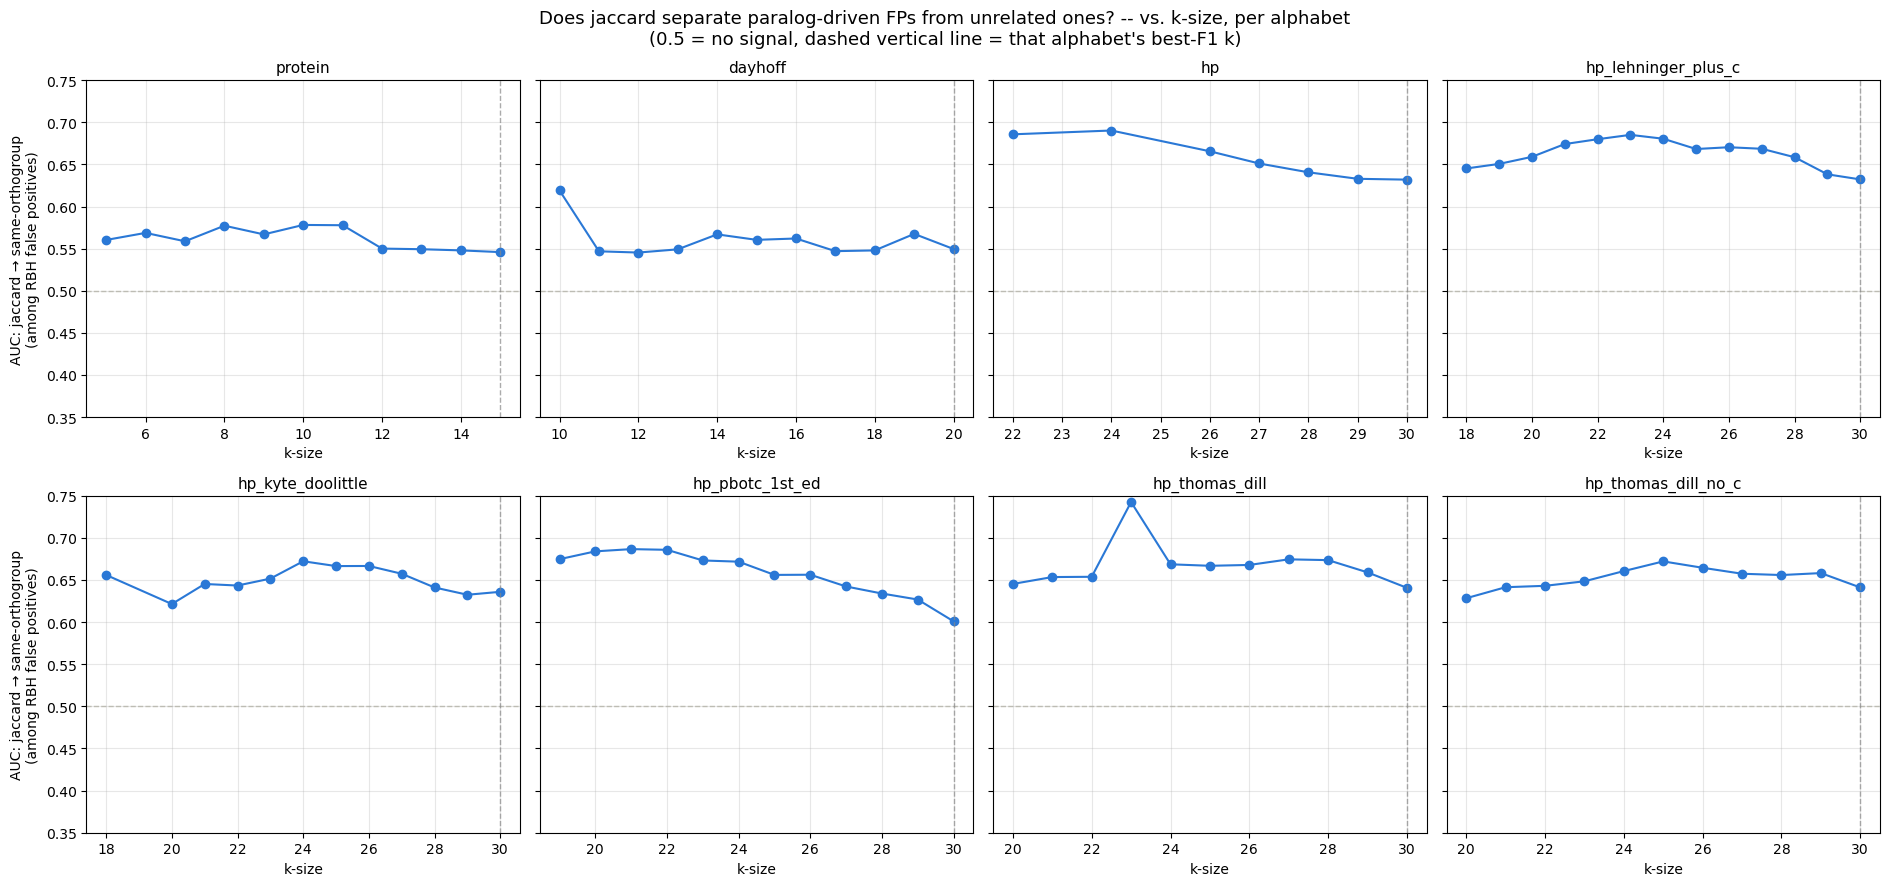

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    sub = jaccard_df.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(sub["ksize"], sub["roc_auc_same_orthogroup"], "o-", color="#2a78d6")
    ax.axhline(0.5, color="#c3c2b7", ls="--", lw=1, zorder=0)
    ax.axvline(best_k_per_alphabet[enc], color="#888888", ls="--", lw=1, alpha=0.7)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("k-size")
    ax.set_ylim(0.35, 0.75)
    ax.grid(True, alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel("AUC: jaccard → same-orthogroup\n(among RBH false positives)")
fig.suptitle(
    "Does jaccard separate paralog-driven FPs from unrelated ones? -- vs. k-size, per alphabet\n"
    "(0.5 = no signal, dashed vertical line = that alphabet's best-F1 k)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "217_jaccard_auc_vs_ksize.png", dpi=150, bbox_inches="tight")

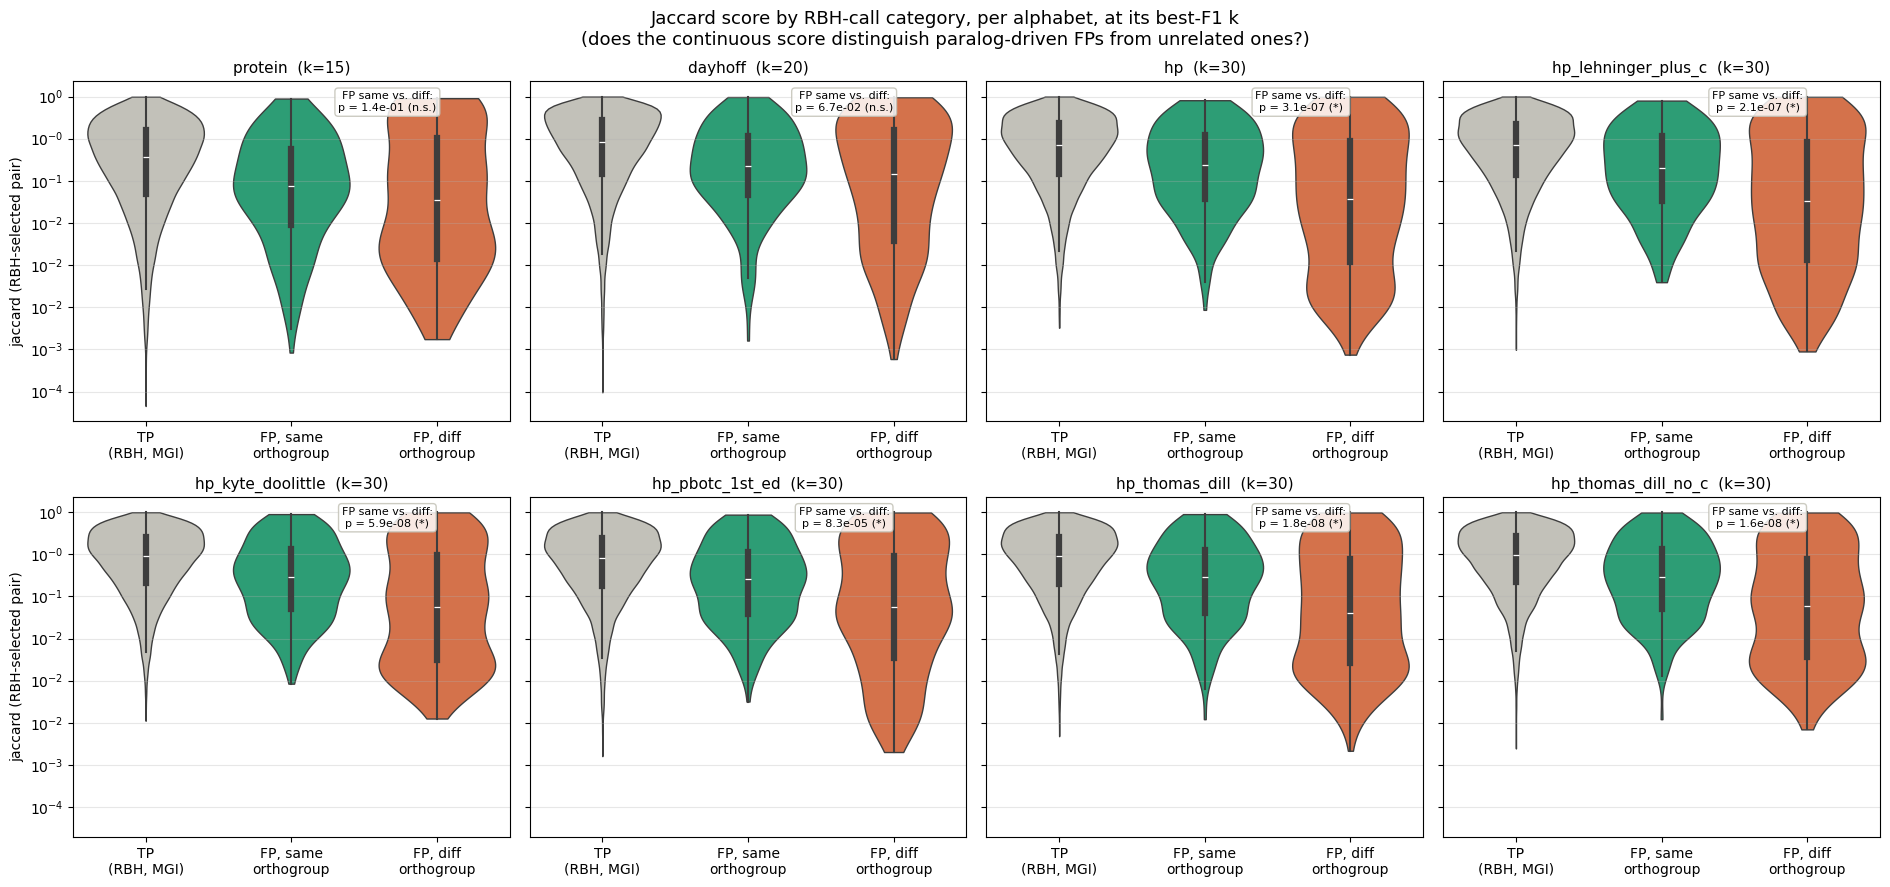

In [10]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

GROUP_ORDER = ["TP\n(RBH, MGI)", "FP, same\northogroup", "FP, diff\northogroup"]
GROUP_COLORS = {
    GROUP_ORDER[0]: "#c3c2b7",
    GROUP_ORDER[1]: "#1baf7a",
    GROUP_ORDER[2]: "#eb6834",
}

# Violin (density) with an inner boxplot (median/IQR) -- log10-transform jaccard first and plot
# on a LINEAR axis with 10^x tick labels, rather than violinplot()+set_yscale("log"): seaborn's
# KDE is computed in the data space it's given, so a KDE fit on raw jaccard then displayed under
# a log-scaled axis distorts the violin shape (bandwidth chosen for linear spacing, rendered
# into log spacing). Fitting the KDE directly on log10(jaccard) avoids that.
#
# Shown at each alphabet's best-F1 k (see the AUC-vs-ksize figure above for the full k-range).
fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    k = best_k_per_alphabet[enc]
    df = rbh_tables_scored[(enc, k)]
    tp = df.filter(pl.col("is_mgi_ortholog"))
    fp_same = df.filter(
        ~pl.col("is_mgi_ortholog") & (pl.col("same_orthogroup") == True)
    )
    fp_diff = df.filter(
        ~pl.col("is_mgi_ortholog") & (pl.col("same_orthogroup") == False)
    )

    plot_df = (
        pl.concat(
            [
                tp.select("jaccard").with_columns(
                    pl.lit(GROUP_ORDER[0]).alias("group")
                ),
                fp_same.select("jaccard").with_columns(
                    pl.lit(GROUP_ORDER[1]).alias("group")
                ),
                fp_diff.select("jaccard").with_columns(
                    pl.lit(GROUP_ORDER[2]).alias("group")
                ),
            ]
        )
        .with_columns(pl.col("jaccard").log10().alias("log_jaccard"))
        .to_pandas()
    )

    sns.violinplot(
        data=plot_df,
        x="group",
        y="log_jaccard",
        order=GROUP_ORDER,
        hue="group",
        palette=GROUP_COLORS,
        inner="box",
        cut=0,
        linewidth=1,
        legend=False,
        ax=ax,
    )
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"$10^{{{v:.0f}}}$"))
    ax.set_title(f"{enc}  (k={k})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.3, axis="y")

    # Annotate the MWU p-value for the comparison this panel actually visualizes: FP-same-OG vs.
    # FP-diff-OG jaccard (the two right-hand violins) -- already computed in jaccard_df, not
    # recomputed here.
    p = jaccard_df.filter((pl.col("encoding") == enc) & (pl.col("ksize") == k))[
        "mwu_pvalue"
    ][0]
    sig = "*" if p < 0.05 else "n.s."
    ax.text(
        0.72,
        0.97,
        f"FP same vs. diff:\np = {p:.1e} ({sig})",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round", fc="white", ec="#c3c2b7", alpha=0.85),
    )
for ax in axes[:, 0]:
    ax.set_ylabel("jaccard (RBH-selected pair)")
fig.suptitle(
    "Jaccard score by RBH-call category, per alphabet, at its best-F1 k\n"
    "(does the continuous score distinguish paralog-driven FPs from unrelated ones?)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "217_jaccard_by_category.png", dpi=150, bbox_inches="tight")

## 5. Redefining TP/FP: orthogroup membership as ground truth, not MGI

Everything above uses MGI as the truth set and asks whether the non-MGI calls still look
biologically related. This section asks the more direct question: what if an RBH call counts as a
hit whenever it lands in a real paralog family at all — same OrthoFinder orthogroup — rather than
only when it matches the single literal MGI-curated pair? MGI documents one best ortholog per gene
and does not credit a call landing on a real but non-canonical family member. Orthogroup membership
is the more permissive, paralog-tolerant ground truth.

For each (alphabet, k-size) combo, `precision_mgi` and `precision_orthogroup` are computed on the
**same denominator** (RBH calls where OrthoFinder has orthogroup data for both genes), so the only
thing that changes between them is which truth definition counts as a hit.

In [11]:
# Reuses rbh_tables (already built in section 2, one row per RBH call with is_mgi_ortholog and
# same_orthogroup) -- no need to re-derive RBH calls or re-join orthogroup data.
precision_rows = []
for (enc, k), df in rbh_tables.items():
    scoreable = df.filter(pl.col("same_orthogroup").is_not_null())
    n_scoreable = scoreable.height
    if n_scoreable == 0:
        continue
    n_tp_mgi = int(scoreable["is_mgi_ortholog"].sum())
    n_tp_orthogroup = int(scoreable["same_orthogroup"].sum())
    precision_rows.append(
        {
            "encoding": enc,
            "ksize": k,
            "n_rbh_calls": df.height,
            "n_scoreable": n_scoreable,
            "precision_mgi": n_tp_mgi / n_scoreable,
            "precision_orthogroup": n_tp_orthogroup / n_scoreable,
            "delta": n_tp_orthogroup / n_scoreable - n_tp_mgi / n_scoreable,
        }
    )
precision_df = pl.DataFrame(precision_rows).sort(["encoding", "ksize"])
print(f"Built precision comparison for {precision_df.height} alphabet/ksize combos")

# Concrete anchor: each alphabet at its best-F1 k.
best_rows = pl.concat(
    [
        precision_df.filter(
            (pl.col("encoding") == enc) & (pl.col("ksize") == best_k_per_alphabet[enc])
        )
        for enc in ENCODINGS
    ]
)
print(
    "\nAt each alphabet's best-F1 k -- same-denominator precision under the two truth definitions:"
)
print(
    best_rows.select(
        [
            "encoding",
            "ksize",
            "n_scoreable",
            "precision_mgi",
            "precision_orthogroup",
            "delta",
        ]
    )
)

Built precision comparison for 88 alphabet/ksize combos

At each alphabet's best-F1 k -- same-denominator precision under the two truth definitions:
shape: (8, 6)
┌─────────────────────┬───────┬─────────────┬───────────────┬──────────────────────┬──────────┐
│ encoding            ┆ ksize ┆ n_scoreable ┆ precision_mgi ┆ precision_orthogroup ┆ delta    │
│ ---                 ┆ ---   ┆ ---         ┆ ---           ┆ ---                  ┆ ---      │
│ str                 ┆ i64   ┆ i64         ┆ f64           ┆ f64                  ┆ f64      │
╞═════════════════════╪═══════╪═════════════╪═══════════════╪══════════════════════╪══════════╡
│ protein             ┆ 15    ┆ 15720       ┆ 0.976145      ┆ 0.986005             ┆ 0.00986  │
│ dayhoff             ┆ 20    ┆ 15787       ┆ 0.970925      ┆ 0.978843             ┆ 0.007918 │
│ hp                  ┆ 30    ┆ 15500       ┆ 0.966968      ┆ 0.974516             ┆ 0.007548 │
│ hp_lehninger_plus_c ┆ 30    ┆ 15461       ┆ 0.96585       ┆ 0.97335

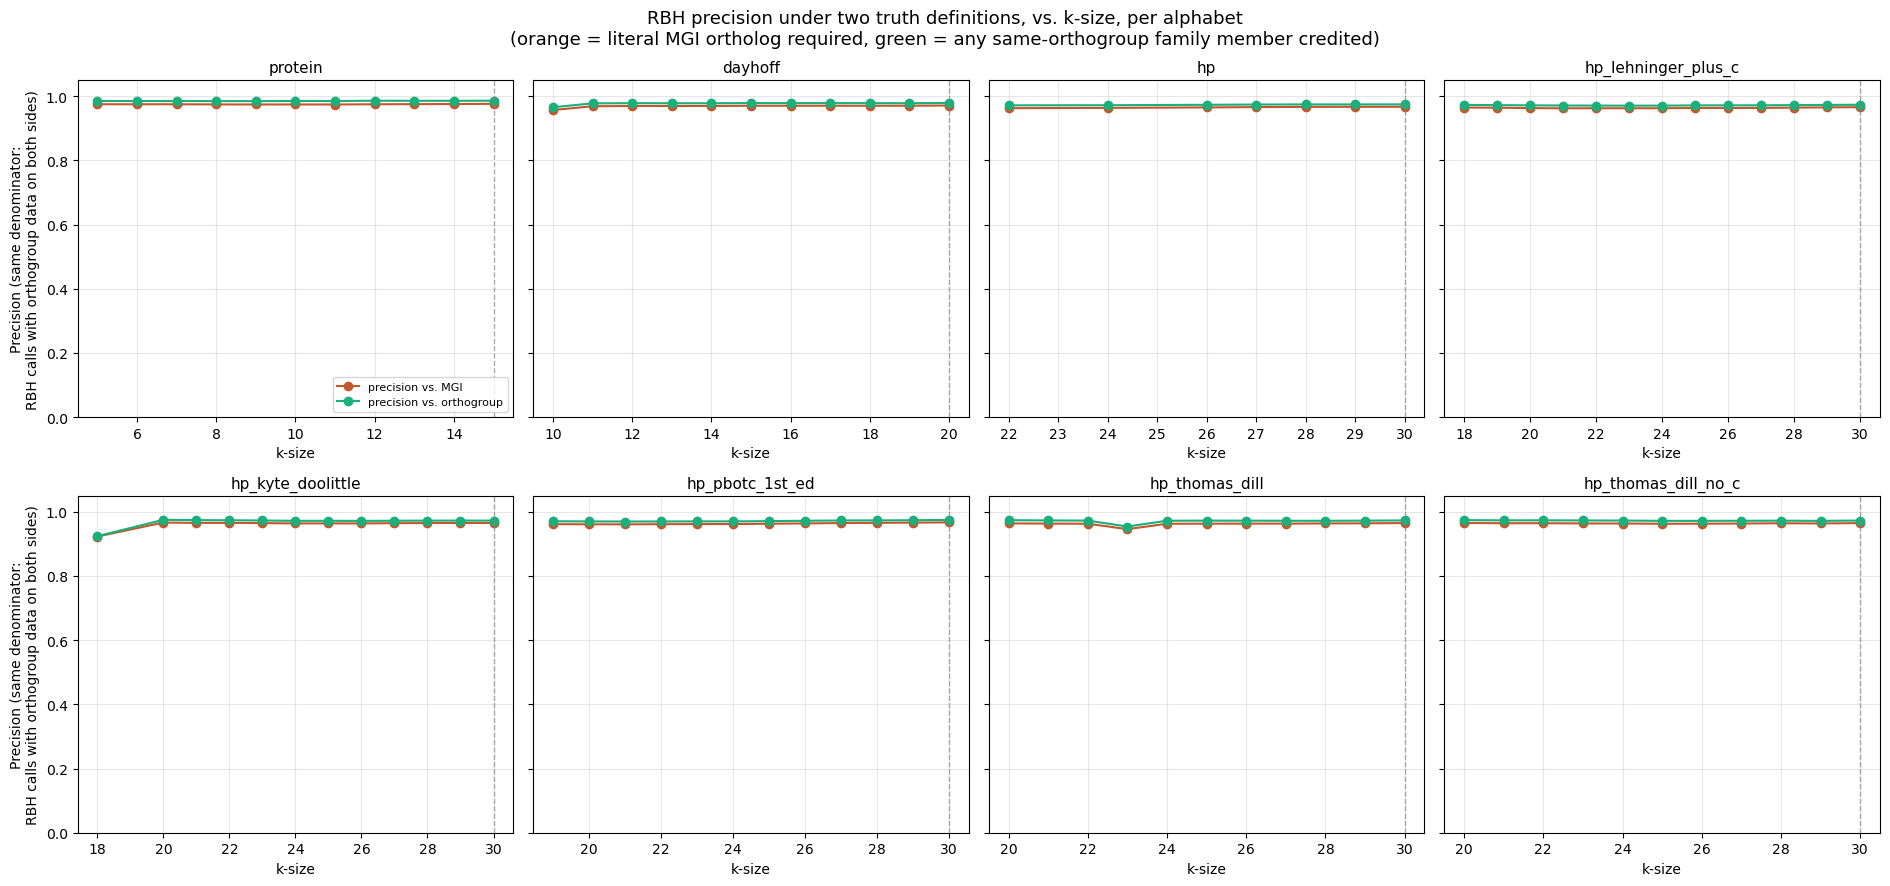

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    sub = precision_df.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(
        sub["ksize"],
        sub["precision_mgi"],
        "o-",
        color="#c3572e",
        label="precision vs. MGI",
    )
    ax.plot(
        sub["ksize"],
        sub["precision_orthogroup"],
        "o-",
        color="#1baf7a",
        label="precision vs. orthogroup",
    )
    ax.axvline(best_k_per_alphabet[enc], color="#888888", ls="--", lw=1, alpha=0.7)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("k-size")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8, loc="lower right")
for ax in axes[:, 0]:
    ax.set_ylabel(
        "Precision (same denominator:\nRBH calls with orthogroup data on both sides)"
    )
fig.suptitle(
    "RBH precision under two truth definitions, vs. k-size, per alphabet\n"
    "(orange = literal MGI ortholog required, green = any same-orthogroup family member credited)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "217_precision_mgi_vs_orthogroup.png", dpi=150, bbox_inches="tight"
)

## 6. Contamination rate and jaccard separation, at each alphabet's best-F1 k

**The false-positive-by-MGI RBH calls are overwhelmingly still same-family, not noise.** Restricted
to pairs where OrthoFinder has orthogroup data for both genes:

| encoding | k | FP same-orthogroup rate | TP same-orthogroup rate (baseline) |
|---|---|---|---|
| protein | 15 | **65.1%** (n=375) | 99.4% |
| dayhoff | 20 | **53.8%** (n=459) | 99.2% |
| hp | 30 | **43.2%** (n=512) | 99.3% |
| hp_lehninger_plus_c | 30 | **42.0%** (n=528) | 99.3% |
| hp_kyte_doolittle | 30 | **42.3%** (n=544) | 99.2% |
| hp_pbotc_1st_ed | 30 | **44.6%** (n=514) | 99.3% |
| hp_thomas_dill | 30 | **42.7%** (n=546) | 99.3% |
| hp_thomas_dill_no_c | 30 | **42.3%** (n=548) | 99.3% |

Every alphabet clears 40%, against a background where random human/mouse gene pairs sharing an
orthogroup would be a fraction of a percent. **Protein is the standout at 65.1%**, ahead of every
reduced alphabet, consistent with its finer-grained sequence signal still tracking real family
structure even when RBH picks the paralogous partner. The five HP variants cluster at 42-45%, not
meaningfully different from plain `hp`: this failure mode does not distinguish between them.

**The continuous jaccard score separates paralog-driven FPs from unrelated ones for the HP-family
alphabets, but not for protein or dayhoff.**

| encoding | median jaccard, FP same-OG | median jaccard, FP diff-OG | MWU p-value | AUC (jaccard → same-OG) |
|---|---|---|---|---|
| protein | 0.088 | 0.059 | 0.14 (n.s.) | 0.546 |
| dayhoff | 0.150 | 0.121 | 0.067 (n.s.) | 0.550 |
| hp | 0.154 | 0.060 | 3.1e-7 | 0.632 |
| hp_lehninger_plus_c | 0.142 | 0.057 | 2.1e-7 | 0.632 |
| hp_kyte_doolittle | 0.171 | 0.075 | 5.9e-8 | 0.636 |
| hp_pbotc_1st_ed | 0.159 | 0.076 | 8.3e-5 | 0.601 |
| hp_thomas_dill | 0.171 | 0.063 | 1.8e-8 | 0.641 |
| hp_thomas_dill_no_c | 0.170 | 0.078 | 1.6e-8 | 0.641 |

For every HP variant, same-orthogroup false positives score roughly **2-3x higher jaccard** than
different-orthogroup ones (AUC 0.60-0.64, p ≤ 8e-5): a real, moderate graded signal, where
higher-jaccard HP mistakes are disproportionately paralog swaps and lower-jaccard ones
disproportionately coincidental. Protein and dayhoff show the same direction without significance
(p=0.14, p=0.067, AUC≈0.55), so their false-positive jaccard scores do not reliably separate paralog
swap from noise, even though protein has the highest same-family *rate* of any alphabet. Those are
two different properties: protein's false positives are more often real family members, but
identifying that from jaccard alone is harder than for HP. HP's coarser, more coincidence-prone
alphabet pushes truly-unrelated matches down to distinctly lower scores than paralog matches, a
separation protein's more specific signal does not produce as strongly, since its jaccard values are
more uniformly high across both FP flavors.

**Reading so far:** kmerseek's RBH mistakes against MGI are disproportionately picking a paralog
instead of the true ortholog, not calling unrelated genes — the expected failure mode of a
single-best-hit rule on genes with lineage-specific duplication, echoing notebook 200 section 5's
finding that OrthoFinder-missed-but-MGI-true kmerseek pairs also concentrate in large gene families.
This is a cleaner version of notebook 124's question, which used the old Bonferroni threshold and
found only 38.5% among the false positives OrthoFinder could evaluate, with 99.8% of that notebook's
false positives (7.28M pairs) not evaluable at all — likely near-pure noise from an over-permissive
threshold rather than biology.

Sections 7-10 below test whether this holds across k, how much precision it actually buys, whether
it transfers to the MHC benchmark, and which specific gene families are responsible.

## 7. Does this hold across k-sizes, or only at each alphabet's best-F1 k?

Section 6 showed each alphabet's single best-F1 k. Repeating both checks across the full k-range (72
alphabet/ksize combos, section 2's sweep) shows two different behaviors:

**The contamination rate is stable across k for most alphabets.** Protein holds ~65-71% across
k=5-15; `hp`/`hp_lehninger_plus_c`/`hp_pbotc_1st_ed` hold ~40-45% across their full k18-30 range.
Not universal: `hp_kyte_doolittle` and `hp_thomas_dill` both dip sharply at their smallest k (to
~0.15-0.26) before settling into the same ~0.42-0.43 plateau from roughly k=24 onward, so those two
need a longer k before the pattern stabilizes.

**The jaccard/paralog AUC signal is generally stronger at lower-to-mid k than at each alphabet's
best-F1 k.** Best-F1 k was chosen to optimize RBH ortholog-calling accuracy, not this
paralog-discrimination question, and the two do not peak at the same place. For
**`hp_pbotc_1st_ed` at k=19**:

| k | n same-OG FPs | median jaccard, same-OG | n diff-OG FPs | median jaccard, diff-OG | MWU p-value | AUC |
|---|---|---|---|---|---|---|
| 19 | 261 | 0.240 | 356 | 0.096 | 1.2e-13 | **0.675** |
| 30 (best-F1 k, section 6) | 229 | 0.159 | 285 | 0.076 | 8.3e-5 | 0.601 |

k=19 separates paralog-driven from unrelated false positives better than k=30 on both effect size
(AUC) and significance, on a comparable-sized false-positive set. The same pattern holds for the
other HP variants (AUC generally highest in the k19-24 range, easing off toward k=30) and more
weakly for protein/dayhoff (AUC stays modestly above 0.5 across their whole k-range without reaching
the HP variants' significance anywhere). See the two per-alphabet trend figures above.

## 8. How much precision credit does orthogroup-as-truth buy? (section 5)

Sections 3-4/7 ask what fraction of the small MGI-false-positive slice is still same-family. Section
5 asks the bottom-line question: if "hit" is redefined from "the literal MGI pair" to "any
same-orthogroup family member", on the identical denominator, how much does overall precision move?

**A small, consistent bump of roughly +0.75 to +1.0 percentage points, in every alphabet, across
essentially the whole k-sweep.** At each alphabet's best-F1 k: protein 97.6%→98.6% (+0.99pp); the
five HP variants 96.5-97.0%→97.2-97.5% (+0.75-0.83pp); dayhoff 97.1%→97.9% (+0.79pp). The same band
holds through most of the 72-combo sweep (protein +0.99 to +1.10pp; the HP variants mostly +0.75 to
+0.95pp), with one outlier: `hp_kyte_doolittle` dips to **+0.11pp** at its smallest, least-stable k,
the same k-range where section 7 found its contamination rate had not settled.

**Why the bump is small, and why that does not conflict with sections 3-4.** MGI precision is
already ~96.5-97.6% before any orthogroup credit, so there is little room for a more permissive
ground truth to add. The paralog-swap failure mode (40-65% of *false positives* are same-family) is
real and dominant *within* that slice, but the slice is only ~2-4% of all RBH calls. "Most mistakes
are paralog swaps, not noise" and "there are few mistakes to begin with, so redefining what counts
as a mistake barely moves precision" are both true: the first is about the *composition* of errors,
the second about their *volume*.

## 9. Best k for MHC: does hp_pbotc_1st_ed k=19, or small k generally, also win there?

Everything above is genome-wide. Notebooks 210/211 built and scored the harder, hand-curated 25-gene
MHC query (`210_mhc_pair_table.parquet`) across every alphabet/k-size combo under three label
policies, reused here as-is. That table established that the class I k-direction reverses relative to
genome-wide (see [[mhc_thomas_dill_k26_verdict]]). Sections 3-4/7 above found a related but distinct
pattern: the genome-wide paralog-vs-noise jaccard signal for HP alphabets peaks around k19-24, well
below their genome-wide-optimal k=30. This section checks whether MHC ortholog *detection* itself,
as opposed to the paralog-contamination question, shows the same small-k advantage, using
`containment` as the ranking score and `synteny_nearest` as the label — notebook 211's headline
policy, the only one under which class I (one-to-many) and class II (1:1) ROC-AUC are comparable.

In [13]:
from sklearn.metrics import roc_auc_score

mhc_pair = pl.read_parquet(DATA_DIR / "210_mhc_pair_table.parquet")

MHC_GROUPS = {
    "class I (A/B/C/E/F/G)": pl.col("mhc_class").str.starts_with("I ")
    & ~pl.col("mhc_class").str.contains("MIC"),
    "class II (a+b)": pl.col("mhc_class").str.starts_with("II"),
}
HEADLINE_POLICY = "synteny_nearest"

mhc_auc_rows = []
for combo in mhc_pair["combo"].unique().to_list():
    sub_all = mhc_pair.filter(pl.col("combo") == combo)
    enc, k = sub_all["encoding"][0], sub_all["ksize"][0]
    for gname, expr in MHC_GROUPS.items():
        sub = sub_all.filter(expr)
        if sub.height == 0:
            continue
        y = sub[f"label_{HEADLINE_POLICY}"].to_numpy().astype(int)
        if y.sum() == 0 or y.sum() == len(y):
            continue  # AUC undefined -- skipped rather than imputed, same rule as notebook 211
        s = sub["containment"].to_numpy()
        mhc_auc_rows.append(
            {
                "encoding": enc,
                "ksize": k,
                "group": gname,
                "roc_auc": roc_auc_score(y, s),
                "n": len(y),
                "n_pos": int(y.sum()),
            }
        )

mhc_auc_df = pl.DataFrame(mhc_auc_rows).sort(["group", "encoding", "ksize"])
print(
    f"MHC ROC-AUC ({HEADLINE_POLICY} labels, containment score): {mhc_auc_df.height} rows "
    f"across {mhc_auc_df['encoding'].n_unique()} alphabets"
)

print("\nThe combo asked about, hp_pbotc_1st_ed k=19, both MHC groups:")
mhc_auc_df.filter((pl.col("encoding") == "hp-pbotc-1st-ed") & (pl.col("ksize") == 19))

MHC ROC-AUC (synteny_nearest labels, containment score): 141 rows across 8 alphabets

The combo asked about, hp_pbotc_1st_ed k=19, both MHC groups:


encoding,ksize,group,roc_auc,n,n_pos
str,i64,str,f64,i64,i64
"""hp-pbotc-1st-ed""",19,"""class I (A/B/C/E/F/G)""",0.990134,23918,6
"""hp-pbotc-1st-ed""",19,"""class II (a+b)""",0.999947,28991,10


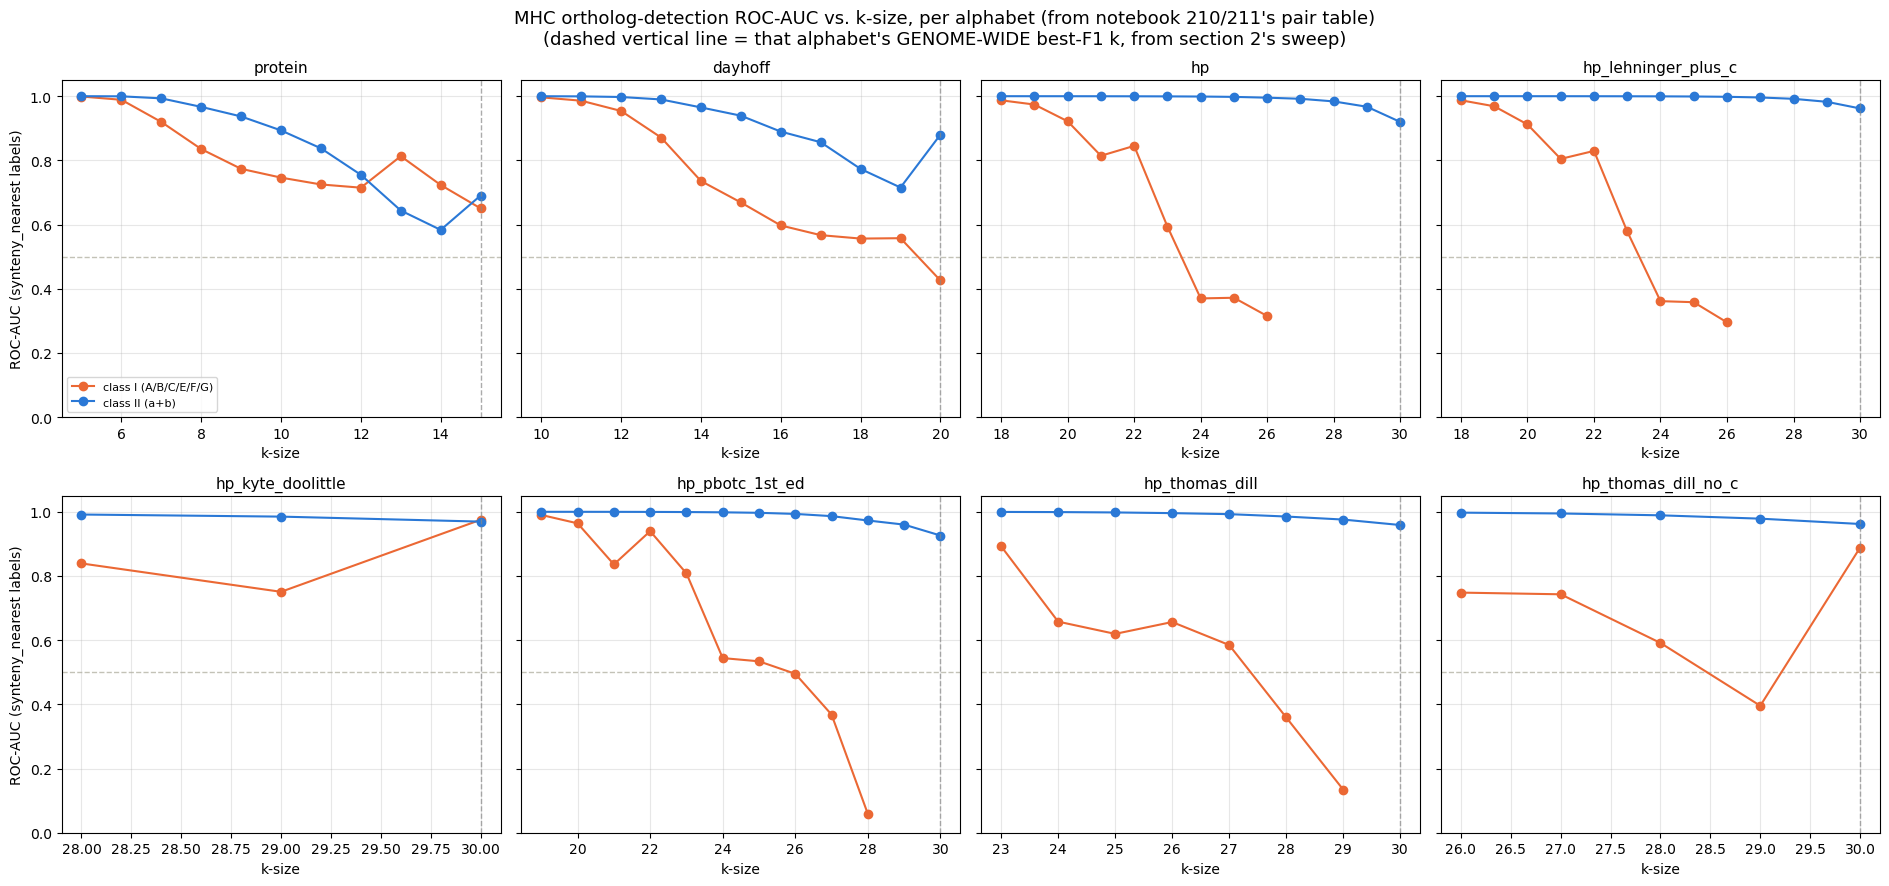

In [14]:
# "hp" itself has no rows in 210's table (dropped there as byte-identical to hp_lehninger --
# same substitution notebook 200 already uses); fall back to hp_lehninger's curve for that panel.
def mhc_file_encoding(enc: str) -> str:
    fenc = file_encoding(enc)
    return "hp-lehninger" if fenc == "hp" else fenc


GROUP_COLORS = {"class I (A/B/C/E/F/G)": "#eb6834", "class II (a+b)": "#2a78d6"}

fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    fenc = mhc_file_encoding(enc)
    for gname, color in GROUP_COLORS.items():
        sub = mhc_auc_df.filter(
            (pl.col("encoding") == fenc) & (pl.col("group") == gname)
        ).sort("ksize")
        if sub.height == 0:
            continue
        ax.plot(sub["ksize"], sub["roc_auc"], "o-", color=color, label=gname)
    ax.axhline(0.5, color="#c3c2b7", ls="--", lw=1, zorder=0)
    ax.axvline(best_k_per_alphabet[enc], color="#888888", ls="--", lw=1, alpha=0.7)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("k-size")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel(f"ROC-AUC ({HEADLINE_POLICY} labels)")
fig.suptitle(
    "MHC ortholog-detection ROC-AUC vs. k-size, per alphabet (from notebook 210/211's pair table)\n"
    "(dashed vertical line = that alphabet's GENOME-WIDE best-F1 k, from section 2's sweep)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "217_mhc_auc_vs_ksize.png", dpi=150, bbox_inches="tight")

In [15]:
# Direct answer to "does hp_pbotc_1st_ed k=19 do an even better job [for MHC]?"
focus = mhc_auc_df.filter(pl.col("encoding") == "hp-pbotc-1st-ed").sort(
    ["group", "ksize"]
)
print("hp_pbotc_1st_ed, MHC ROC-AUC across its full k-range:")
print(focus)

for gname in MHC_GROUPS:
    sub = focus.filter(pl.col("group") == gname)
    if sub.height == 0:
        continue
    best = sub.sort("roc_auc", descending=True).head(1).to_dicts()[0]
    at_19 = sub.filter(pl.col("ksize") == 19).to_dicts()
    at_genome_wide_best = sub.filter(
        pl.col("ksize") == best_k_per_alphabet["hp_pbotc_1st_ed"]
    ).to_dicts()
    print(f"\n{gname}:")
    print(
        f"  best k overall:            k={best['ksize']}  ROC-AUC={best['roc_auc']:.3f}  (n_pos={best['n_pos']}/{best['n']})"
    )
    if at_19:
        print(
            f"  k=19:                      ROC-AUC={at_19[0]['roc_auc']:.3f}  (n_pos={at_19[0]['n_pos']}/{at_19[0]['n']})"
        )
    if at_genome_wide_best:
        r = at_genome_wide_best[0]
        print(
            f"  genome-wide-best k={r['ksize']}: ROC-AUC={r['roc_auc']:.3f}  (n_pos={r['n_pos']}/{r['n']})"
        )

hp_pbotc_1st_ed, MHC ROC-AUC across its full k-range:
shape: (22, 6)
┌─────────────────┬───────┬───────────────────────┬──────────┬───────┬───────┐
│ encoding        ┆ ksize ┆ group                 ┆ roc_auc  ┆ n     ┆ n_pos │
│ ---             ┆ ---   ┆ ---                   ┆ ---      ┆ ---   ┆ ---   │
│ str             ┆ i64   ┆ str                   ┆ f64      ┆ i64   ┆ i64   │
╞═════════════════╪═══════╪═══════════════════════╪══════════╪═══════╪═══════╡
│ hp-pbotc-1st-ed ┆ 19    ┆ class I (A/B/C/E/F/G) ┆ 0.990134 ┆ 23918 ┆ 6     │
│ hp-pbotc-1st-ed ┆ 20    ┆ class I (A/B/C/E/F/G) ┆ 0.963983 ┆ 13273 ┆ 6     │
│ hp-pbotc-1st-ed ┆ 21    ┆ class I (A/B/C/E/F/G) ┆ 0.835975 ┆ 7167  ┆ 6     │
│ hp-pbotc-1st-ed ┆ 22    ┆ class I (A/B/C/E/F/G) ┆ 0.939627 ┆ 3707  ┆ 5     │
│ hp-pbotc-1st-ed ┆ 23    ┆ class I (A/B/C/E/F/G) ┆ 0.808083 ┆ 1935  ┆ 5     │
│ …               ┆ …     ┆ …                     ┆ …        ┆ …     ┆ …     │
│ hp-pbotc-1st-ed ┆ 26    ┆ class II (a+b)        ┆ 0.993349 ┆

## 10. All-HGNC-family breakdown: does an independent curated ground truth agree, and which families drive the contamination?

Sections 3-4/7 established that RBH's MGI-false-positives are majority same-orthogroup paralog
swaps, using OrthoFinder's *computationally inferred* orthogroups. HGNC's gene-family groupings
(`gene_group`) are a different, manually *curated* source, so this is a cross-check rather than a
restatement. It also generalizes notebook 206 section 4's hand-picked family list (olfactory
receptors, CYP2/CYP3, antiviral restriction factors, sperm/testis) to **every** HGNC family with
>=15 protein-coding genes, via `ou.load_hgnc_family_gene_sets`. That answers a question the single
pooled orthogroup rate cannot: which *specific* families are responsible for the contamination, not
just how much there is overall. Tandem-repeat C2H2 zinc-finger families are excluded by default, the
same confound notebook 206 section 6 flags: repeat content inflates k-mer sharing independent of
real homology.

`same_hgnc_family` (new in `ortholog_analysis_utils.py`) looks the mouse gene's uppercased symbol up
directly as if it were a human HGNC symbol. HGNC curates only human genes, so this relies on MGI's
nomenclature convention of giving a mouse paralog the same base symbol as its human counterpart
(mouse Trim21 reads as human TRIM21's family). Reuses `rbh_tables` (section 2) at each alphabet's
best-F1 k, so there is no new RBH computation, only a new annotation on calls already made.

In [16]:
family_gene_sets = (
    ou.load_hgnc_family_gene_sets()
)  # min_family_size=15, zinc-finger families excluded
symbol_to_families = ou.hgnc_symbol_to_families(family_gene_sets)
print(
    f"{len(family_gene_sets)} HGNC families with >=15 protein-coding genes "
    f"(zinc-finger families excluded -- see notebook 206 section 6)"
)
print(f"{len(symbol_to_families):,} distinct human gene symbols covered")

# Pooled rate first (same shape as section 3's orthogroup table) -- an overall cross-check that
# an independently curated ground truth (HGNC) agrees with the computationally inferred one
# (OrthoFinder) before drilling into which specific families drive it.
hgnc_pooled_rows = []
for enc in ENCODINGS:
    k = best_k_per_alphabet[enc]
    df = rbh_tables[(enc, k)].with_columns(
        pl.struct(["human_gene", "mouse_gene"])
        .map_elements(
            lambda r: ou.same_hgnc_family(
                r["human_gene"], r["mouse_gene"], symbol_to_families
            ),
            return_dtype=pl.Boolean,
        )
        .alias("same_hgnc_family")
    )
    fp_scoreable = df.filter(
        ~pl.col("is_mgi_ortholog") & pl.col("same_hgnc_family").is_not_null()
    )
    tp_scoreable = df.filter(
        pl.col("is_mgi_ortholog") & pl.col("same_hgnc_family").is_not_null()
    )
    hgnc_pooled_rows.append(
        {
            "encoding": enc,
            "ksize": k,
            "n_fp_scoreable": fp_scoreable.height,
            "fp_same_hgnc_family_rate": (
                fp_scoreable["same_hgnc_family"].mean()
                if fp_scoreable.height
                else float("nan")
            ),
            "n_tp_scoreable": tp_scoreable.height,
            "tp_same_hgnc_family_rate": (
                tp_scoreable["same_hgnc_family"].mean()
                if tp_scoreable.height
                else float("nan")
            ),
        }
    )

hgnc_pooled_df = pl.DataFrame(hgnc_pooled_rows)
# Inner join restricts contamination_df's full 72-combo sweep down to just these 8 best-k rows --
# no separate pre-filter needed, the join itself does the restricting.
compare_df = hgnc_pooled_df.join(
    contamination_df.select(
        ["encoding", "ksize", "fp_same_orthogroup_rate", "tp_same_orthogroup_rate"]
    ),
    on=["encoding", "ksize"],
)
print(
    "\nHGNC (curated) vs. OrthoFinder (inferred) -- same pooled FP contamination question, two independent sources:"
)
print(
    compare_df.select(
        [
            "encoding",
            "ksize",
            "n_fp_scoreable",
            "fp_same_hgnc_family_rate",
            "fp_same_orthogroup_rate",
        ]
    )
)

279 HGNC families with >=15 protein-coding genes (zinc-finger families excluded -- see notebook 206 section 6)
9,228 distinct human gene symbols covered

HGNC (curated) vs. OrthoFinder (inferred) -- same pooled FP contamination question, two independent sources:
shape: (8, 5)
┌─────────────────────┬───────┬────────────────┬─────────────────────────┬─────────────────────────┐
│ encoding            ┆ ksize ┆ n_fp_scoreable ┆ fp_same_hgnc_family_rat ┆ fp_same_orthogroup_rate │
│ ---                 ┆ ---   ┆ ---            ┆ e                       ┆ ---                     │
│ str                 ┆ i64   ┆ i64            ┆ ---                     ┆ f64                     │
│                     ┆       ┆                ┆ f64                     ┆                         │
╞═════════════════════╪═══════╪════════════════╪═════════════════════════╪═════════════════════════╡
│ dayhoff             ┆ 20    ┆ 87             ┆ 1.0                     ┆ 0.538126                │
│ hp            

In [17]:
# Per-family breakdown: for every RBH call, explode over every HGNC family the HUMAN gene
# belongs to (a gene can be in >1 family), and ask whether the MOUSE gene is a member of that
# SAME specific family -- a per-family version of the pooled same_hgnc_family check above.
family_frames = []
for enc in ENCODINGS:
    k = best_k_per_alphabet[enc]
    df = rbh_tables[(enc, k)]
    exploded = [
        (fam, is_mgi, m.upper() in family_gene_sets[fam])
        for h, m, is_mgi in zip(
            df["human_gene"].to_list(),
            df["mouse_gene"].to_list(),
            df["is_mgi_ortholog"].to_list(),
        )
        for fam in symbol_to_families.get(h.upper(), ())
    ]
    if not exploded:
        continue
    fam_df = pl.DataFrame(
        exploded, schema=["family", "is_mgi_ortholog", "mouse_in_family"], orient="row"
    )
    agg = (
        fam_df.group_by("family")
        .agg(
            [
                (~pl.col("is_mgi_ortholog")).sum().alias("n_fp"),
                (~pl.col("is_mgi_ortholog") & pl.col("mouse_in_family"))
                .sum()
                .alias("n_fp_within_family"),
                pl.col("is_mgi_ortholog").sum().alias("n_tp"),
                (pl.col("is_mgi_ortholog") & pl.col("mouse_in_family"))
                .sum()
                .alias("n_tp_within_family"),
            ]
        )
        .with_columns([pl.lit(enc).alias("encoding"), pl.lit(k).alias("ksize")])
    )
    family_frames.append(agg)

family_contam_df = pl.concat(family_frames).with_columns(
    [
        (pl.col("n_fp_within_family") / pl.col("n_fp")).alias("fp_within_family_rate"),
        (pl.col("n_tp_within_family") / pl.col("n_tp")).alias("tp_within_family_rate"),
    ]
)
print(
    f"Per-family contamination rows: {family_contam_df.height} (family x alphabet), "
    f"{family_contam_df['family'].n_unique()} distinct families touched by >=1 RBH call"
)

# Each alphabet's total FP pool is only ~400-550 pairs spread across up to 279 families, so
# requiring a single family to independently clear a floor in 3+ of those small, separate pools
# (an earlier version of this cell) left almost nothing standing. Pool n_fp/n_fp_within_family
# ACROSS all 8 alphabets first (sum, not per-alphabet-then-median), then apply one floor to the
# pooled total -- the min-max range across alphabets is still reported, just not gating inclusion.
FAMILY_N_FLOOR = 15  # pooled FPs (summed across alphabets) required before a family's rate is reported

family_ranked = (
    family_contam_df.group_by("family")
    .agg(
        [
            pl.len().alias("n_alphabets_touched"),
            pl.col("n_fp").sum().alias("total_n_fp"),
            pl.col("n_fp_within_family").sum().alias("total_n_fp_within_family"),
            pl.col("fp_within_family_rate").min().alias("min_rate"),
            pl.col("fp_within_family_rate").max().alias("max_rate"),
        ]
    )
    .filter(pl.col("total_n_fp") >= FAMILY_N_FLOOR)
    .with_columns(
        (pl.col("total_n_fp_within_family") / pl.col("total_n_fp")).alias("pooled_rate")
    )
    .sort("pooled_rate", descending=True)
)
print(
    f"\n{family_ranked.height} families with >= {FAMILY_N_FLOOR} FPs pooled across all 8 alphabets"
)
print("\nTop 20 families by pooled FP-within-family contamination rate:")
print(family_ranked.head(20))
print("\nBottom 10 (least contamination-prone, of families that clear the floor):")
print(family_ranked.tail(10))

Per-family contamination rows: 2208 (family x alphabet), 278 distinct families touched by >=1 RBH call

46 families with >= 15 FPs pooled across all 8 alphabets

Top 20 families by pooled FP-within-family contamination rate:
shape: (20, 7)
┌────────────────┬────────────────┬────────────┬───────────────┬──────────┬──────────┬─────────────┐
│ family         ┆ n_alphabets_to ┆ total_n_fp ┆ total_n_fp_wi ┆ min_rate ┆ max_rate ┆ pooled_rate │
│ ---            ┆ uched          ┆ ---        ┆ thin_family   ┆ ---      ┆ ---      ┆ ---         │
│ str            ┆ ---            ┆ u32        ┆ ---           ┆ f64      ┆ f64      ┆ f64         │
│                ┆ u32            ┆            ┆ u32           ┆          ┆          ┆             │
╞════════════════╪════════════════╪════════════╪═══════════════╪══════════╪══════════╪═════════════╡
│ ARF GTPase     ┆ 8              ┆ 43         ┆ 43            ┆ 1.0      ┆ 1.0      ┆ 1.0         │
│ family         ┆                ┆            ┆     

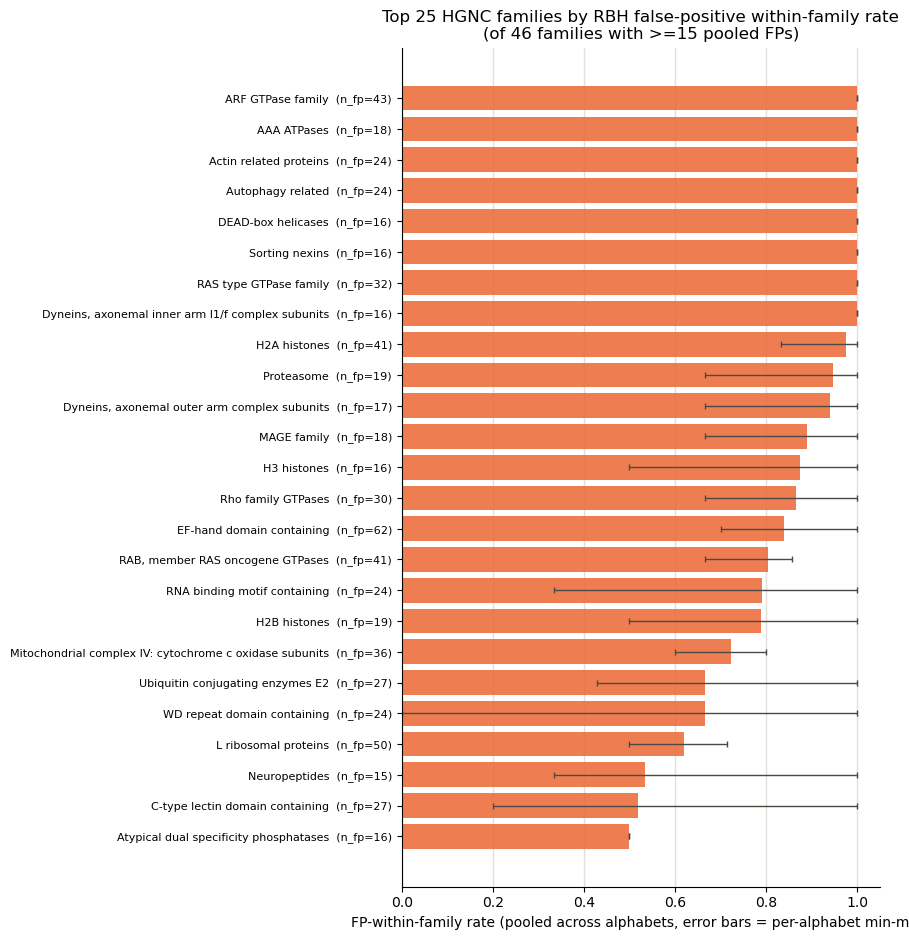

In [18]:
TOP_N = 25
top = family_ranked.head(TOP_N).sort(
    "pooled_rate"
)  # ascending for barh (top of chart = highest)

fig, ax = plt.subplots(figsize=(9, 0.32 * TOP_N + 1.5))
y = np.arange(top.height)
ax.barh(
    y,
    top["pooled_rate"],
    color="#eb6834",
    alpha=0.85,
    xerr=[top["pooled_rate"] - top["min_rate"], top["max_rate"] - top["pooled_rate"]],
    error_kw=dict(ecolor="#4a4a45", elinewidth=1, capsize=2),
)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{f}  (n_fp={n:,})" for f, n in zip(top["family"], top["total_n_fp"])], fontsize=8
)
ax.set_xlabel(
    "FP-within-family rate (pooled across alphabets, error bars = per-alphabet min-max)"
)
ax.set_xlim(0, 1.05)
ax.set_title(
    f"Top {TOP_N} HGNC families by RBH false-positive within-family rate\n"
    f"(of {family_ranked.height} families with >={FAMILY_N_FLOOR} pooled FPs)"
)
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(
    DATA_DIR / "217_hgnc_family_contamination_top25.png", dpi=150, bbox_inches="tight"
)

### Reading section 10

**HGNC (curated) agrees with OrthoFinder (inferred) in direction, but the two numbers are not
directly comparable.** The pooled HGNC same-family rate (87.5-100% across alphabets) looks much
higher than the orthogroup rate (42-65%), but this is not a stronger version of the same result:
HGNC's `min_family_size=15` restricts "scoreable" to genes that already belong to a curated
family of 15+ members (62-126 FPs per alphabet, vs. orthogroup's 375-548) -- a strong selection
toward exactly the genes most likely to have lineage-specific duplicates and therefore an
RBH-picks-the-wrong-paralog error to begin with. The two checks corroborate the same underlying
biology from independent data sources; they are not measuring the same denominator.

**The per-family breakdown names the actual offenders sections 3-4/7's pooled rate could not.**
46 families clear the pooled n>=15 floor. The rate is 100% (every single FP in that family is a
within-family paralog swap, 0 pure noise) for DEAD-box helicases, AAA ATPases, autophagy-related
proteins, sorting nexins, axonemal inner-arm dyneins, actin-related proteins, and the ARF and RAS
GTPase families -- canonical large, highly-duplicated multigene families, exactly where a
single-best-hit rule is structurally expected to pick the wrong close paralog. Histones (H2A,
H3, H2B), the RAB/Rho GTPase families, and the axonemal outer-arm dyneins cluster just below at
79-98%. The lowest rates among families that clear the floor (~50-53%: atypical dual-specificity
phosphatases, C-type lectin domain-containing, neuropeptides) still sit well above what random
gene-pair overlap would produce, consistent with sections 3-4's headline finding holding broadly
rather than being carried by one or two extreme families.

## Verdict

RBH's MGI-false-positives are mostly paralog swaps, not noise. At each alphabet's best-F1 k-size,
the share of non-MGI RBH calls whose two genes still share an OrthoFinder orthogroup runs 65.1%
for protein (n=375), 53.8% for dayhoff (n=459), and 42.0-44.6% for the five HP variants (n=512-548),
against a true-positive baseline of 99.2-99.4% and a random-pair background of well under a percent.
The reduced alphabets are not making a different kind of mistake than protein; they are making the
same mistake more often, and the five HP variants are indistinguishable from each other on it.

The failure mode is legible in the continuous score, but only for HP. Jaccard separates
same-orthogroup false positives from different-orthogroup ones with ROC-AUC 0.600-0.641 for the HP
alphabets (MWU p from 1.6e-8 to 8.3e-5), while protein and dayhoff sit at 0.546 and 0.550 with
p-values of 0.14 and 0.067, which is no separation. A paralog swap carries real k-mer signal onto
the wrong duplicate and an HP jaccard registers that; protein jaccard at k=15 does not.

Best-F1 k is the wrong k for this question. `hp_pbotc_1st_ed` at k=19 reaches AUC 0.675 with median
jaccard 0.240 for same-orthogroup false positives against 0.096 for different-orthogroup ones
(p=1.2e-13), clearly better than the same alphabet at its genome-wide-best k=30. Best-F1 k was tuned
for ortholog-calling accuracy, and paralog discrimination does not peak in the same place.
`hp_kyte_doolittle` and `hp_thomas_dill` also need k of roughly 24 or more before their contamination
rate settles onto the 42-43% plateau; below that they dip to 0.15-0.26 and should not be read.

Redefining truth barely moves the headline. Scored on the identical denominator, swapping "the
literal MGI pair" for "any same-orthogroup family member" adds only +0.75 to +1.0 percentage points
of precision in every alphabet (protein 97.6% to 98.6%, HP variants 96.5-97.0% to 97.2-97.5%,
dayhoff 97.1% to 97.9%), and holds across most of the 72-combo sweep. That is not in tension with
the 40-65% contamination rate: MGI precision is already ~96.5-97.6%, so the false-positive slice
being reclassified is small to begin with. The paralog-swap story is about what the errors *are*,
not about how many there are.

HGNC corroborates from an independently curated source, with a caveat that has to travel with the
number. Pooled same-HGNC-family rates of 87.5-100% are much higher than the orthogroup rates, but
the `min_family_size=15` filter cuts the scoreable set to 62-126 false positives per alphabet
against orthogroup's 375-548, selecting precisely the genes most likely to have lineage-specific
duplicates. Direction agrees; the two rates are not comparable numbers. The per-family breakdown is
the part the pooled rate could not give: of the 46 families clearing the pooled n>=15 floor, ARF and
RAS GTPases, AAA ATPases, DEAD-box helicases, autophagy-related proteins, sorting nexins, axonemal
inner-arm dyneins and actin-related proteins contaminate at 100%, meaning every false positive in
those families is a within-family swap and none is noise.

Section 9's MHC result points the same way as section 7 but rests on very few positives.
`hp_pbotc_1st_ed` k=19 is the best k for both MHC groups under 211's synteny_nearest policy, at
ROC-AUC 0.990 for class I and 1.000 for class II, against 0.926 for class II at the genome-wide-best
k=30. The positive sets are 6 and 10 genes, and the k=30 table has collapsed to 33 rows, so this
supports "small k is not worse for MHC" and should not be quoted as a precise AUC.

Two limits on the sweep as run. Nine of the 97 alphabet/ksize combos had no `pair_cache` entry and
were skipped, including `hp_thomas_dill` and `hp_thomas_dill_no_c` at k=18 and k=19, which is the
exact k-range where section 7 finds the paralog signal strongest. Filling those in is the obvious
next run. And `same_hgnc_family` resolves mouse symbols by uppercasing them against human HGNC, so
mouse genes whose symbol diverged from the human one are silently unscoreable rather than counted as
misses.